# Depth-Anything-V2: From PyTorch to ONNX and OpenVINO (Quantized)

This notebook demonstrates the complete deployment pipeline for **Depth-Anything-V2 Metric Depth Estimation**, from PyTorch inference to ONNX Runtime and OpenVINO INT8 inference.

**Pipeline Stages:**
1. **PyTorch Inference:** Compare the Official Repository and Hugging Face Transformers using the same ViT-Small metric-depth checkpoint.
2. **Multi-Image Evaluation:** Evaluate the PyTorch implementations on the same known NYU Depth V2 validation images using ground-truth depth.
3. **ONNX Export & Profiling:** Export the Hugging Face model, validate the ONNX graph, and run inference with ONNX Runtime.
4. **OpenVINO & NNCF:** Convert the ONNX model to OpenVINO IR and apply INT8 post-training quantization using real calibration images rather than random noise.
5. **Deployment Comparison:** Compare output quality, inference time, and memory/model size where appropriate.

**Goal:**
The experiment separates visual demonstration from quantitative evaluation. The official repository and Hugging Face implementations use the same model family and metric-depth task, but their preprocessing can differ, so their results are treated as an interface/preprocessing comparison rather than a pure architecture comparison.

The quantitative depth metrics are calculated against held-out NYU Depth V2 ground-truth depth maps. The selected subset is a controlled evaluation subset, not a full benchmark.


In [ ]:
!pip install -q transformers accelerate onnx onnxruntime onnxscript openvino nncf datasets huggingface_hub matplotlib
!git clone -q https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2/metric_depth
!pip install -q -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.0/795.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.4 MB/s eta 0:00:00
/content/Depth-Anything-V2/metric_depth
ERROR: Could not find a version that satisfies the requirement open3d (from versions: none)
ERROR: No matching distribution found for open3d


In [ ]:
import os
import sys
import cv2
import time
import shutil
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import onnx
import onnxruntime as ort
import openvino as ov
import nncf

from pathlib import Path
from PIL import Image
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

sys.path.append('/content/Depth-Anything-V2/metric_depth')
from depth_anything_v2.dpt import DepthAnythingV2

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device available: {device}")
print(f"ONNX Runtime providers: {ort.get_available_providers()}")

## Model Checkpoints

The official repository and Hugging Face model use the same **Depth-Anything-V2 ViT-Small metric-depth model for indoor scenes**. The official checkpoint is loaded from the portfolio dataset, while the Transformers checkpoint is loaded from the corresponding Hugging Face model.

The official repository notes that predictions can differ slightly from Transformers because the preprocessing/upsampling path is different. Therefore, identical outputs are not expected even when the model family and checkpoint are matched.


In [ ]:
checkpoint_path = hf_hub_download(
    repo_id="WasiqSaleem/Portfolio_Assest",
    filename="depth_anything_v2_metric_hypersim_vits.pth",
    repo_type="dataset"
)

hf_model_id = "depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf"

encoder = "vits"
max_depth = 20

model_configs = {
    "vits": {"encoder": "vits", "features": 64, "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]}
}

print(f"Official checkpoint: {checkpoint_path}")
print(f"Hugging Face checkpoint: {hf_model_id}")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


depth_anything_v2_metric_hypersim_vits.p(…): reconstructing file:   0%|          |  0.00B / 99.2MB            

depth_anything_v2_metric_hypersim_vits.p(…): downloading bytes:           |  0.00B            

Official checkpoint: /root/.cache/huggingface/hub/datasets--WasiqSaleem--Portfolio_Assest/snapshots/a1f34c054c7c612df30c553723a2db9db7ccfaf1/depth_anything_v2_metric_hypersim_vits.pth
Hugging Face checkpoint: depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf


## Reference Evaluation Dataset

For quantitative evaluation we use the **NYU Depth V2 validation split**, which contains aligned RGB images and dense depth maps. The dataset stores depth maps as 16-bit TIFF images in millimeters, so the code converts them back to meters before calculating the metrics.

We use a fixed subset of the validation split for this controlled study. The same RGB images and ground-truth depth maps are used for every implementation and deployment format.


In [ ]:
EVAL_SIZE = 20
CALIBRATION_SIZE = 50

nyu_val = load_dataset("jagennath-hari/nyuv2", split="val")

print(f"NYU Depth V2 validation samples available: {len(nyu_val)}")
print(f"Evaluation subset: {EVAL_SIZE} images")
print(f"Calibration subset: {CALIBRATION_SIZE} images")

depth_scale_path = hf_hub_download(
    repo_id="jagennath-hari/nyuv2",
    filename="scaling_factors.json",
    repo_type="dataset"
)

with open(depth_scale_path) as f:
    depth_scale = json.load(f)["depth_scale"]

print(f"Depth scale: {depth_scale}")


In [ ]:
eval_indices = np.linspace(0, len(nyu_val) - 1, EVAL_SIZE, dtype=int).tolist()

remaining_indices = [i for i in range(len(nyu_val)) if i not in set(eval_indices)]
calib_positions = np.linspace(0, len(remaining_indices) - 1, CALIBRATION_SIZE, dtype=int).tolist()
calibration_indices = [remaining_indices[i] for i in calib_positions]

assert set(eval_indices).isdisjoint(set(calibration_indices)), "Calibration/eval overlap!"

eval_samples = [nyu_val[i] for i in eval_indices]
calibration_samples = [nyu_val[i] for i in calibration_indices]

sample = eval_samples[0]
image = sample["rgb"].convert("RGB")
depth_gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

print(f"RGB image size: {image.size}")
print(f"Ground-truth depth shape: {depth_gt.shape}")
print(f"Valid ground-truth pixels: {(depth_gt > 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("NYU RGB")
axes[0].axis("off")
axes[1].imshow(depth_gt, cmap="magma")
axes[1].set_title("Ground-Truth Depth (m)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Official Repository

The official implementation expects an OpenCV image and returns an H×W depth map. Since the notebook images are stored as RGB PIL images, they are converted to OpenCV BGR before calling `infer_image()`.


In [ ]:
model_official = DepthAnythingV2(
    **{**model_configs[encoder], "max_depth": max_depth}
)

model_official.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
model_official = model_official.to(device).eval()

print("Official model loaded.")


In [ ]:
def official_predict(image):
    image_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    with torch.no_grad():
        depth = model_official.infer_image(image_bgr)
    return depth

depth_official = official_predict(image)

print(f"Official output shape: {depth_official.shape}")

plt.figure(figsize=(6, 5))
plt.imshow(depth_official, cmap="magma")
plt.title("Official Repository")
plt.axis("off")
plt.show()


## Hugging Face Transformers

The Hugging Face implementation uses the corresponding **Depth-Anything-V2-Metric-Indoor-Small-hf** checkpoint and its official image processor. The predicted depth is post-processed back to the original image resolution.


In [ ]:
processor = AutoImageProcessor.from_pretrained(hf_model_id)
model_hf = AutoModelForDepthEstimation.from_pretrained(
    hf_model_id
).to(device).eval()

print("Hugging Face model loaded.")
print(f"Depth estimation type: {model_hf.config.depth_estimation_type}")
print(f"Maximum metric depth: {model_hf.config.max_depth}")


In [ ]:
def hf_predict(image):
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    print("HF input device:", inputs["pixel_values"].device)
    print("HF model device:", next(model_hf.parameters()).device)

    with torch.no_grad():
        outputs = model_hf(**inputs)
    predicted = processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(image.height, image.width)]
    )[0]["predicted_depth"]

    return predicted.detach().cpu().numpy()

depth_hf = hf_predict(image)

print(f"Hugging Face output shape: {depth_hf.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(depth_official, cmap="magma")
axes[1].set_title("Official Repository")
axes[1].axis("off")
axes[2].imshow(depth_hf, cmap="magma")
axes[2].set_title("Hugging Face")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Depth Evaluation Metrics

For metric depth estimation we compare predicted depth against the aligned ground-truth depth.

The evaluation reports:

- **Abs Rel:** mean absolute relative error.
- **RMSE:** root mean squared depth error in meters.
- **δ1, δ2, δ3:** percentage of valid pixels where the ratio between prediction and ground truth is below 1.25, 1.25², and 1.25³.

No median scaling is applied because this experiment evaluates a **metric-depth model** rather than converting relative depth into an arbitrary metric scale.

Invalid ground-truth pixels are excluded from the calculation.


In [ ]:
def depth_metrics(pred, gt):
    pred = np.asarray(pred, dtype=np.float32)
    gt = np.asarray(gt, dtype=np.float32)

    valid = np.isfinite(gt) & np.isfinite(pred) & (gt > 0) & (pred > 0)
    pred = pred[valid]
    gt = gt[valid]

    abs_rel = np.mean(np.abs(pred - gt) / gt)
    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    ratio = np.maximum(pred / gt, gt / pred)

    delta1 = np.mean(ratio < 1.25)
    delta2 = np.mean(ratio < 1.25 ** 2)
    delta3 = np.mean(ratio < 1.25 ** 3)

    return {
        "Abs Rel": abs_rel,
        "RMSE (m)": rmse,
        "Delta < 1.25": delta1,
        "Delta < 1.25^2": delta2,
        "Delta < 1.25^3": delta3,
    }

print(depth_metrics(depth_hf, depth_gt))


## Multi-Image PyTorch Evaluation

A single image is useful for checking whether the pipeline works, but it is not sufficient for a meaningful comparison. We therefore evaluate both implementations on the same fixed validation subset with the same ground-truth depth maps and metric definitions.

This is a **controlled evaluation subset**, not a full NYU Depth V2 benchmark.


In [ ]:
def evaluate_model(predict_fn, samples):
    all_metrics = []
    times = []

    for sample in samples:
        image = sample["rgb"].convert("RGB")
        gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

        start = time.perf_counter()
        pred = predict_fn(image)
        elapsed = time.perf_counter() - start

        metrics = depth_metrics(pred, gt)
        metrics["time (s)"] = elapsed
        all_metrics.append(metrics)
        times.append(elapsed)

    df = pd.DataFrame(all_metrics)

    summary = {
        "Abs Rel": df["Abs Rel"].mean(),
        "RMSE (m)": df["RMSE (m)"].mean(),
        "Delta < 1.25": df["Delta < 1.25"].mean(),
        "Delta < 1.25^2": df["Delta < 1.25^2"].mean(),
        "Delta < 1.25^3": df["Delta < 1.25^3"].mean(),
        "Mean Inference Time (s)": np.mean(times),
    }

    return df, summary

official_metrics_df, official_summary = evaluate_model(official_predict, eval_samples)
hf_metrics_df, hf_summary = evaluate_model(hf_predict, eval_samples)

pytorch_comparison = pd.DataFrame(
    [official_summary, hf_summary],
    index=["Official Repository", "Hugging Face"]
)

print(pytorch_comparison)


In [ ]:
sample_id = 0
sample = eval_samples[sample_id]
image = sample["rgb"].convert("RGB")
gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

pred_official = official_predict(image)
pred_hf = hf_predict(image)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="magma")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_official, cmap="magma")
axes[2].set_title("Official Repository")
axes[2].axis("off")

axes[3].imshow(pred_hf, cmap="magma")
axes[3].set_title("Hugging Face")
axes[3].axis("off")

plt.tight_layout()
plt.show()


## ONNX Export

The ONNX model is exported from the Hugging Face model. The export uses the same 518×518 input resolution used by the model configuration.

The exported graph is checked with the ONNX checker and shape inference before inference is attempted.


In [ ]:
INPUT_SIZE = 518

class ONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, pixel_values):
        return self.model(pixel_values).predicted_depth

model_hf_cpu = AutoModelForDepthEstimation.from_pretrained(
    hf_model_id
).to("cpu").eval()

wrapper = ONNXWrapper(model_hf_cpu).eval()
dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)

print("Exporting to ONNX...")

torch.onnx.export(
    wrapper,
    dummy_input,
    "depth_anything_v2.onnx",
    input_names=["pixel_values"],
    output_names=["depth"],
    dynamic_axes={
        "pixel_values": {0: "batch_size", 2: "height", 3: "width"},
        "depth": {0: "batch_size", 2: "height", 3: "width"},
    },
    opset_version=17,
)

onnx_model = onnx.load("depth_anything_v2.onnx")
onnx.checker.check_model(onnx_model)

print("ONNX graph is valid.")


In [ ]:
from onnx import shape_inference

onnx_model = shape_inference.infer_shapes(onnx_model)
onnx.save(onnx_model, "depth_anything_v2_shape_inferred.onnx")
onnx_size_mb = os.path.getsize("depth_anything_v2_shape_inferred.onnx") / (1024 ** 2)

print(f"Shape inference complete.")
print(f"ONNX model size: {onnx_size_mb:.2f} MB")


## ONNX Runtime Inference

For a controlled deployment comparison, the ONNX Runtime experiment uses the CPU provider. This avoids comparing a GPU PyTorch run directly against a CPU ONNX run.

The preprocessing is kept explicit so that the ONNX model receives the same normalized input representation used for export.


In [ ]:
ort_session = ort.InferenceSession(
    "depth_anything_v2_shape_inferred.onnx",
    providers=["CPUExecutionProvider"]
)

print(f"Active ONNX Runtime providers: {ort_session.get_providers()}")

preprocess_onnx = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def onnx_predict(image):
    img_tensor = preprocess_onnx(image).unsqueeze(0).numpy().astype(np.float32)
    output = ort_session.run(None, {"pixel_values": img_tensor})[0]
    return cv2.resize(
        output[0],
        (image.width, image.height),
        interpolation=cv2.INTER_LINEAR
    )

onnx_test = onnx_predict(eval_samples[0]["rgb"].convert("RGB"))
print(f"ONNX output shape: {onnx_test.shape}")


In [ ]:
def evaluate_onnx(samples):
    all_metrics = []
    times = []

    for sample in samples:
        image = sample["rgb"].convert("RGB")
        gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

        start = time.perf_counter()
        pred = onnx_predict(image)
        elapsed = time.perf_counter() - start

        metrics = depth_metrics(pred, gt)
        metrics["time (s)"] = elapsed
        all_metrics.append(metrics)
        times.append(elapsed)

    df = pd.DataFrame(all_metrics)

    summary = {
        "Abs Rel": df["Abs Rel"].mean(),
        "RMSE (m)": df["RMSE (m)"].mean(),
        "Delta < 1.25": df["Delta < 1.25"].mean(),
        "Delta < 1.25^2": df["Delta < 1.25^2"].mean(),
        "Delta < 1.25^3": df["Delta < 1.25^3"].mean(),
        "Mean Inference Time (s)": np.mean(times),
    }

    return df, summary

onnx_metrics_df, onnx_summary = evaluate_onnx(eval_samples)

print(pd.DataFrame([onnx_summary], index=["ONNX Runtime"]))


## ONNX Runtime Profiling

The profiling session records runtime events and graph execution information. This is separate from the quality evaluation above: profiling explains execution behavior, while depth metrics measure prediction quality.


In [ ]:
options = ort.SessionOptions()
options.enable_profiling = True
options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session_prof = ort.InferenceSession(
    "depth_anything_v2_shape_inferred.onnx",
    providers=["CPUExecutionProvider"],
    sess_options=options
)

warmup_image = eval_samples[0]["rgb"].convert("RGB")
warmup_tensor = preprocess_onnx(warmup_image).unsqueeze(0).numpy().astype(np.float32)

session_prof.run(None, {"pixel_values": warmup_tensor})
profiling_file = session_prof.end_profiling()

print(f"Profiling data saved to: {profiling_file}")


## OpenVINO Conversion

The validated ONNX model is converted to OpenVINO IR. The converted model is then compiled for CPU inference.


In [ ]:
core = ov.Core()
print(f"Available OpenVINO devices: {core.available_devices}")

ov_model = ov.convert_model("depth_anything_v2_shape_inferred.onnx")
ov.save_model(ov_model, "depth_anything_v2.xml")

print("OpenVINO IR saved.")


## Real Calibration Data for INT8 PTQ

Random noise is not an appropriate calibration dataset for a production quantization experiment. Calibration data should represent the input distribution seen by the model.

Here we use real RGB images from the NYU Depth V2 validation split. The same domain is appropriate for this indoor metric-depth model, although the calibration subset is separate from the evaluation subset.

The calibration images are preprocessed using the same normalization as the ONNX/OpenVINO input.


In [ ]:
def make_calibration_data(samples):
    calibration_data = []

    for sample in samples:
        image = sample["rgb"].convert("RGB")
        img_tensor = preprocess_onnx(image).unsqueeze(0).numpy().astype(np.float32)
        calibration_data.append({"pixel_values": img_tensor})

    return calibration_data

calibration_data = make_calibration_data(calibration_samples)
calibration_dataset = nncf.Dataset(calibration_data)

print(f"Calibration samples prepared: {len(calibration_data)}")


## NNCF Post-Training Quantization

The model is quantized using NNCF INT8 post-training quantization. The quantized model is evaluated on the same held-out validation subset used for the floating-point deployment model.

This makes the quantization comparison a controlled experiment: calibration data and evaluation data are separated, while the evaluation images, preprocessing, and metric definitions remain fixed.


In [ ]:
print("Running INT8 quantization...")

quantized_model = nncf.quantize(
    ov_model,
    calibration_dataset,
    preset=nncf.QuantizationPreset.MIXED,
    target_device=nncf.TargetDevice.CPU
)

ov.save_model(quantized_model, "depth_anything_v2_quantized.xml")

print("Quantized OpenVINO model saved.")


In [ ]:
compiled_fp32 = core.compile_model(
    "depth_anything_v2.xml",
    "CPU"
)

compiled_int8 = core.compile_model(
    "depth_anything_v2_quantized.xml",
    "CPU"
)

input_name_fp32 = compiled_fp32.input(0).get_any_name()
input_name_int8 = compiled_int8.input(0).get_any_name()

print(f"FP32 input: {input_name_fp32}")
print(f"INT8 input: {input_name_int8}")


## OpenVINO Inference

Both FP32 and INT8 OpenVINO models use the same input tensors and evaluation subset. Synchronous inference is used here because it gives a straightforward per-image latency measurement.

The asynchronous API is demonstrated afterward as a separate deployment example.


In [ ]:
def openvino_predict(compiled_model, input_name, image):
    img_tensor = preprocess_onnx(image).unsqueeze(0).numpy().astype(np.float32)
    result = compiled_model({input_name: img_tensor})
    output = next(iter(result.values()))

    return cv2.resize(
        output[0],
        (image.width, image.height),
        interpolation=cv2.INTER_LINEAR
    )

ov_fp32_test = openvino_predict(
    compiled_fp32,
    input_name_fp32,
    eval_samples[0]["rgb"].convert("RGB")
)

ov_int8_test = openvino_predict(
    compiled_int8,
    input_name_int8,
    eval_samples[0]["rgb"].convert("RGB")
)

print(f"OpenVINO FP32 output shape: {ov_fp32_test.shape}")
print(f"OpenVINO INT8 output shape: {ov_int8_test.shape}")


In [ ]:
def evaluate_openvino(compiled_model, input_name, samples):
    all_metrics = []
    times = []

    for sample in samples:
        image = sample["rgb"].convert("RGB")
        gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

        start = time.perf_counter()
        pred = openvino_predict(compiled_model, input_name, image)
        elapsed = time.perf_counter() - start

        metrics = depth_metrics(pred, gt)
        metrics["time (s)"] = elapsed
        all_metrics.append(metrics)
        times.append(elapsed)

    df = pd.DataFrame(all_metrics)

    summary = {
        "Abs Rel": df["Abs Rel"].mean(),
        "RMSE (m)": df["RMSE (m)"].mean(),
        "Delta < 1.25": df["Delta < 1.25"].mean(),
        "Delta < 1.25^2": df["Delta < 1.25^2"].mean(),
        "Delta < 1.25^3": df["Delta < 1.25^3"].mean(),
        "Mean Inference Time (s)": np.mean(times),
    }

    return df, summary

ov_fp32_metrics_df, ov_fp32_summary = evaluate_openvino(
    compiled_fp32, input_name_fp32, eval_samples
)

ov_int8_metrics_df, ov_int8_summary = evaluate_openvino(
    compiled_int8, input_name_int8, eval_samples
)

deployment_comparison = pd.DataFrame(
    [hf_summary, onnx_summary, ov_fp32_summary, ov_int8_summary],
    index=[
        "Hugging Face PyTorch",
        "ONNX Runtime",
        "OpenVINO FP32",
        "OpenVINO INT8"
    ]
)

print(deployment_comparison)


## FP32 vs INT8 Quantization Comparison

The important question is not only whether INT8 inference runs, but whether quantization changes prediction quality on the held-out evaluation images.

We compare the same depth metrics before and after quantization. Any change is therefore measured rather than assumed.


In [ ]:
quantization_comparison = pd.DataFrame(
    {
        "FP32": ov_fp32_summary,
        "INT8": ov_int8_summary
    }
)

print(quantization_comparison)

print("\nINT8 - FP32:")
for key in quantization_comparison.index:
    print(f"{key}: {quantization_comparison.loc[key, 'INT8'] - quantization_comparison.loc[key, 'FP32']:.6f}")


In [ ]:
sample = eval_samples[1]
image = sample["rgb"].convert("RGB")
gt = np.array(sample["depth"]).astype(np.float32) / depth_scale

pred_hf = hf_predict(image)
pred_onnx = onnx_predict(image)
pred_ov_fp32 = openvino_predict(compiled_fp32, input_name_fp32, image)
pred_ov_int8 = openvino_predict(compiled_int8, input_name_int8, image)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(image)
axes[0, 0].set_title("RGB")
axes[0, 0].axis("off")

axes[0, 1].imshow(gt, cmap="magma")
axes[0, 1].set_title("Ground Truth")
axes[0, 1].axis("off")

axes[0, 2].imshow(pred_hf, cmap="magma")
axes[0, 2].set_title("Hugging Face PyTorch")
axes[0, 2].axis("off")

axes[1, 0].imshow(pred_onnx, cmap="magma")
axes[1, 0].set_title("ONNX Runtime")
axes[1, 0].axis("off")

axes[1, 1].imshow(pred_ov_fp32, cmap="magma")
axes[1, 1].set_title("OpenVINO FP32")
axes[1, 1].axis("off")

axes[1, 2].imshow(pred_ov_int8, cmap="magma")
axes[1, 2].set_title("OpenVINO INT8")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


## OpenVINO Asynchronous Inference

The asynchronous API is useful when inference needs to overlap with other work or when multiple inference requests are being scheduled. This cell demonstrates the API separately from the synchronous metric evaluation.


In [ ]:
sample = eval_samples[0]["rgb"].convert("RGB")
img_tensor = preprocess_onnx(sample).unsqueeze(0).numpy().astype(np.float32)

infer_request = compiled_int8.create_infer_request()
infer_request.set_tensor(
    input_name_int8,
    ov.Tensor(img_tensor)
)

start = time.perf_counter()
infer_request.start_async()
infer_request.wait()
async_time = time.perf_counter() - start

output_async = infer_request.get_output_tensor().data
print(f"Async output shape: {output_async.shape}")
print(f"Async request time: {async_time:.4f} seconds")


## Model Size

Model size is reported as a deployment property rather than as an accuracy metric. INT8 compression can reduce storage and memory requirements, but the exact runtime benefit depends on the hardware and execution configuration.


In [ ]:
def file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

model_sizes = pd.DataFrame(
    {
        "File": [
            "ONNX",
            "OpenVINO FP32 XML",
            "OpenVINO INT8 XML"
        ],
        "Size (MB)": [
            file_size_mb("depth_anything_v2_shape_inferred.onnx"),
            file_size_mb("depth_anything_v2.xml"),
            file_size_mb("depth_anything_v2_quantized.xml")
        ]
    }
)

print(model_sizes)


## Final Results

The final table combines the main quantitative results.

The interpretation should remain limited to this experiment:

- **PyTorch Official vs Hugging Face:** controlled interface/preprocessing comparison using the same metric-depth model family.
- **ONNX Runtime:** deployment-format comparison against the Hugging Face PyTorch path.
- **OpenVINO FP32:** alternate inference runtime for the exported model.
- **OpenVINO INT8:** post-training quantized deployment using real calibration images.
- **Metrics:** computed against known NYU Depth V2 ground truth on the selected validation subset.
- **Latency:** measured in the actual Colab CPU execution environment and should not be treated as a hardware-independent benchmark.

A lower Abs Rel/RMSE is better. Higher δ values are better.

This is a controlled multi-image experiment, not a full benchmark of Depth-Anything-V2.


In [ ]:
final_results = pd.DataFrame(
    [
        official_summary,
        hf_summary,
        onnx_summary,
        ov_fp32_summary,
        ov_int8_summary
    ],
    index=[
        "Official Repository",
        "Hugging Face PyTorch",
        "ONNX Runtime",
        "OpenVINO FP32",
        "OpenVINO INT8"
    ]
)

print(final_results.round(4))


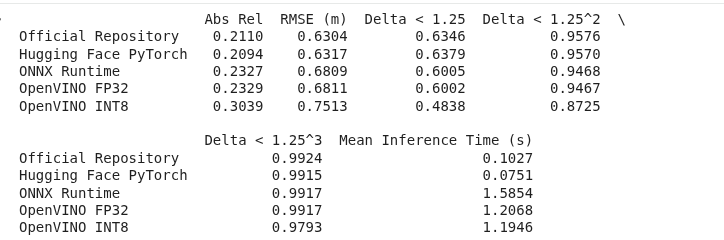

## Interpretation

The Official Repository and Hugging Face PyTorch implementations achieve the best accuracy, with Abs Rel values of 21.10% and 20.94% and RMSE values around 0.63 m. ONNX Runtime and OpenVINO FP32 show slightly lower performance, with Abs Rel around 23.3% and RMSE around 0.68 m, indicating a small accuracy loss during deployment conversion.

The OpenVINO INT8 model has the lowest accuracy, with Abs Rel increasing to 30.39% and RMSE to 0.75 m, while δ < 1.25 falls to 48.38%. Although INT8 is slightly faster than OpenVINO FP32 (1.195 s vs. 1.207 s), the improvement is small compared with the accuracy degradation. Therefore, FP32 is preferable when depth accuracy is the priority, while INT8 may be considered when deployment efficiency is more important.

## Limitations

1. The evaluation uses a fixed subset of the NYU Depth V2 validation split rather than the complete benchmark.
2. NYU Depth V2 is an indoor dataset, which matches the indoor metric-depth checkpoint used here but does not establish performance on outdoor scenes.
3. The official repository and Transformers preprocessing paths are not identical, so differences between those two implementations should not be interpreted as a pure architecture difference.
4. ONNX Runtime and OpenVINO latency is measured on the Colab CPU provider. Results will change with hardware, threading, runtime versions, and system load.
5. INT8 calibration uses real NYU validation images, but the calibration subset is still relatively small compared with a production calibration corpus.
6. The notebook measures depth quality against ground truth; visual similarity of depth maps alone is not treated as evidence of accuracy.


## Research Conclusion

This notebook demonstrates a complete deployment path from a research model to multiple inference representations while keeping the evaluation protocol fixed.

The main evidence is the quantitative multi-image evaluation rather than a single visual example. The notebook also separates model quality from deployment characteristics such as latency, model size, and quantization.

No performance numbers are hard-coded; all reported values in the final table are produced by executing the evaluation code.
